#### Imports and Paths

In [ ]:
import os
import sys
import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [ ]:
# -----------------------------
# Paths
# -----------------------------
PROCESSED_DIR = "../data/processed"
ANALYTICS_CSV = os.path.join(PROCESSED_DIR, "corridor_analytics.csv")

FIGURES_DIR = "../reports/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_show(fig_name: str):
    """
    Save the current matplotlib figure to reports/figures and display it.
    """
    path = os.path.join(FIGURES_DIR, fig_name)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    print("Saved:", path)

#### Load Feature Dataset

In [ ]:
# Load analytics dataset with proper datetime parsing
df = pd.read_csv(ANALYTICS_CSV, parse_dates=["depart_time"])

print("Shape:", df.shape)
df.head()

Shape: (1000, 36)


,shipment_id,truck_id,origin_port,border,destination,depart_time,border_arrival_time,border_exit_time,arrival_time,goods_category,delay_reason,delay_reason_group,weight_kg,declared_value_usd,fuel_price_usd_per_litre,rainfall_indicator,travel_to_border_hours,clearance_hours,travel_to_destination_hours,total_transit_hours,depart_year,depart_month,depart_day,depart_day_name,depart_day_of_week_num,depart_hour,is_weekend,is_high_value,is_heavy,clearance_bucket,transit_bucket,rolling_clearance_mean_30,rolling_clearance_median_30,rolling_delay_rate_30,delay_cost_usd,is_delayed
0,SHP00823,TRK600,Mombasa,Malaba,Kampala,2024-01-01 03:00:00,2024-01-01 14:17:06.805672,2024-01-01 22:48:26.005174,2024-01-02 03:04:38.934531,Fuel,NaN,Other,28351.50,34054.16,1.38,1,11.285224,8.522000,4.270258,24.077482,2024,1,1,Monday,0,3,0,0,0,6–12h,24–36h,NaN,NaN,NaN,0.000000,0
1,SHP00640,TRK331,Mombasa,Malaba,Kampala,2024-01-01 12:00:00,2024-01-02 01:43:29.755472,2024-01-02 06:30:18.284027,2024-01-02 13:46:37.147922,Machinery,NaN,Other,10666.48,12530.05,1.60,1,13.724932,4.780147,7.271907,25.776986,2024,1,1,Monday,0,12,0,0,0,2–6h,24–36h,NaN,NaN,NaN,0.000000,0
2,SHP00639,TRK688,Mombasa,Malaba,Kampala,2024-01-01 16:00:00,2024-01-02 04:14:44.282085,2024-01-03 00:14:44.282085,2024-01-03 07:19:46.547138,Machinery,Weather Disruption,Weather,17593.27,24469.33,1.49,0,12.245634,20.000000,7.083963,39.329596,2024,1,1,Monday,0,16,0,0,0,12–24h,36h+,NaN,NaN,NaN,3000.000000,1
3,SHP00842,TRK761,Mombasa,Malaba,Kampala,2024-01-01 19:00:00,2024-01-02 05:51:33.025321,2024-01-02 17:30:59.349309,2024-01-03 01:07:20.157222,Pharmaceuticals,NaN,Other,3041.22,3616.17,1.45,1,10.859174,11.657312,7.605780,30.122266,2024,1,1,Monday,0,19,0,0,0,6–12h,24–36h,NaN,NaN,NaN,0.000000,0
4,SHP00652,TRK182,Mombasa,Malaba,Kampala,2024-01-02 00:00:00,2024-01-02 09:04:35.317693,2024-01-02 21:31:16.391695,2024-01-03 01:52:40.025551,Pharmaceuticals,Truck Breakdown,Vehicle/Mechanical,5562.38,5554.66,1.45,1,9.076477,12.444743,4.356565,25.877785,2024,1,2,Tuesday,1,0,0,0,0,12–24h,24–36h,NaN,NaN,NaN,1866.711417,1


#### Quick Data Checks

In [ ]:
# -----------------------------
# Quick checks (missing + types)
# -----------------------------
df.info()

missing = df.isnull().mean().sort_values(ascending=False)
display(missing.head(15))

# Delay rate sanity check
print("Delay rate (%):", round(df["is_delayed"].mean() * 100, 2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   shipment_id                  1000 non-null   object        
 1   truck_id                     1000 non-null   object        
 2   origin_port                  1000 non-null   object        
 3   border                       1000 non-null   object        
 4   destination                  1000 non-null   object        
 5   depart_time                  1000 non-null   datetime64[ns]
 6   border_arrival_time          1000 non-null   object        
 7   border_exit_time             1000 non-null   object        
 8   arrival_time                 1000 non-null   object        
 9   goods_category               1000 non-null   object        
 10  delay_reason                 107 non-null    object        
 11  delay_reason_group           1000 non-null  

delay_reason                   0.893
rolling_clearance_median_30    0.009
rolling_clearance_mean_30      0.009
rolling_delay_rate_30          0.009
border                         0.000
origin_port                    0.000
truck_id                       0.000
shipment_id                    0.000
border_exit_time               0.000
destination                    0.000
border_arrival_time            0.000
depart_time                    0.000
weight_kg                      0.000
declared_value_usd             0.000
fuel_price_usd_per_litre       0.000
dtype: float64

Delay rate (%): 10.7


#### Core KPI Summary

In [ ]:
# -----------------------------
# KPI Summary for exec reporting
# -----------------------------
kpis = {
    "shipments": len(df),
    "avg_clearance_hours": df["clearance_hours"].mean(),
    "median_clearance_hours": df["clearance_hours"].median(),
    "p90_clearance_hours": df["clearance_hours"].quantile(0.90),
    "avg_total_transit_hours": df["total_transit_hours"].mean(),
    "delay_rate_pct": df["is_delayed"].mean() * 100,
    "avg_delay_cost_usd": df["delay_cost_usd"].mean(),
    "total_delay_cost_usd": df["delay_cost_usd"].sum()
}

kpi_df = pd.DataFrame([kpis]).T.rename(columns={0: "value"})
kpi_df

,value
shipments,1000.000000
avg_clearance_hours,6.162153
median_clearance_hours,5.187192
p90_clearance_hours,12.312374
avg_total_transit_hours,23.079899
delay_rate_pct,10.700000
avg_delay_cost_usd,241.516318
total_delay_cost_usd,241516.318424


#### Distribution Analysis

##### Clearance time Distribution

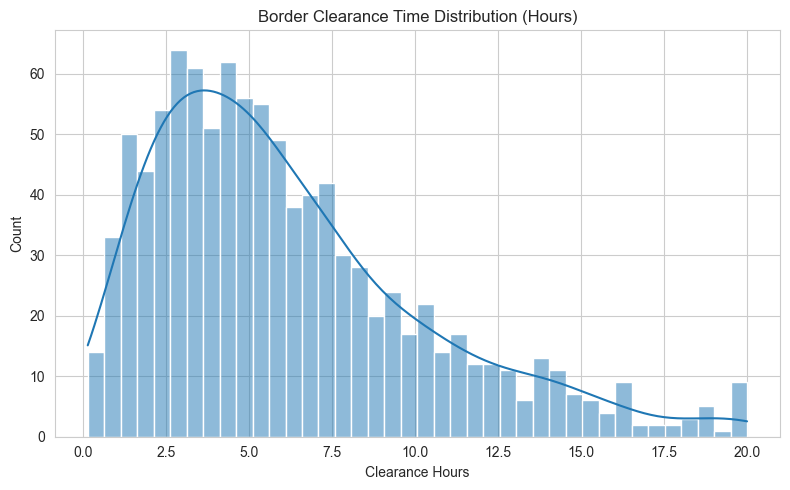

Saved: ../reports/figures\01_clearance_distribution.png


In [ ]:
# -----------------------------
# Clearance time distribution (hist)
# -----------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df["clearance_hours"], bins=40, kde=True)
plt.title("Border Clearance Time Distribution (Hours)")
plt.xlabel("Clearance Hours")
plt.ylabel("Count")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "01_clearance_distribution.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

##### Total Transit time distribution

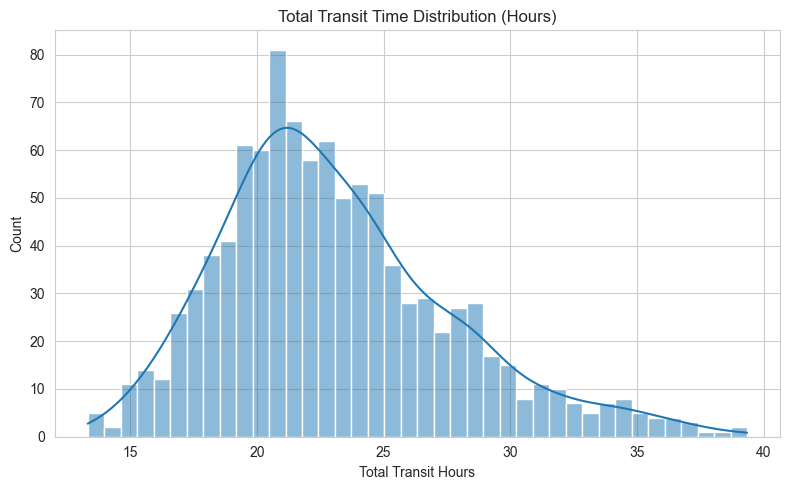

Saved: ../reports/figures\02_transit_distribution.png


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["total_transit_hours"], bins=40, kde=True)
plt.title("Total Transit Time Distribution (Hours)")
plt.xlabel("Total Transit Hours")
plt.ylabel("Count")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "02_transit_distribution.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

#### Segment Analysis(What gets delayed?)

##### Delay rate by goods category

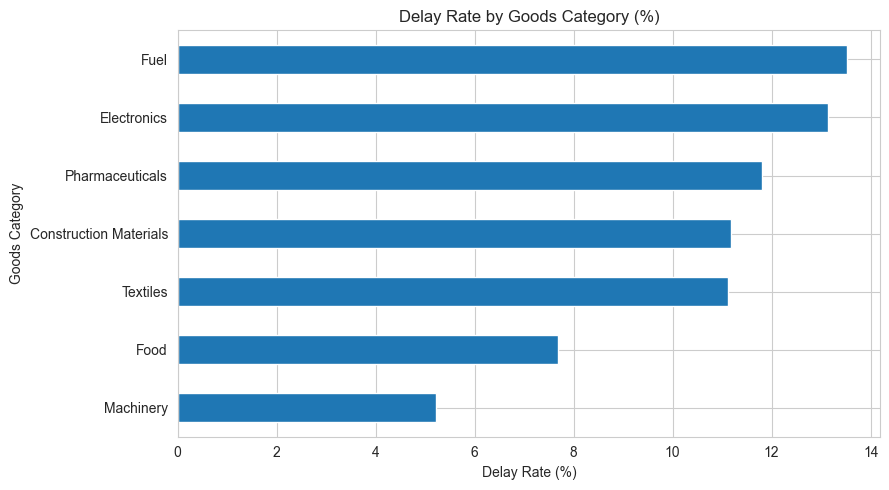

Saved: ../reports/figures\03_delay_by_goods.png


In [ ]:
# -----------------------------
# Delay rate by goods
# -----------------------------
delay_by_goods = (
    df.groupby("goods_category")["is_delayed"]
      .mean()
      .sort_values(ascending=True) * 100
)

plt.figure(figsize=(9, 5))
delay_by_goods.plot(kind="barh")
plt.title("Delay Rate by Goods Category (%)")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Goods Category")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "03_delay_by_goods.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

##### Clearance time by goods category (boxplot)

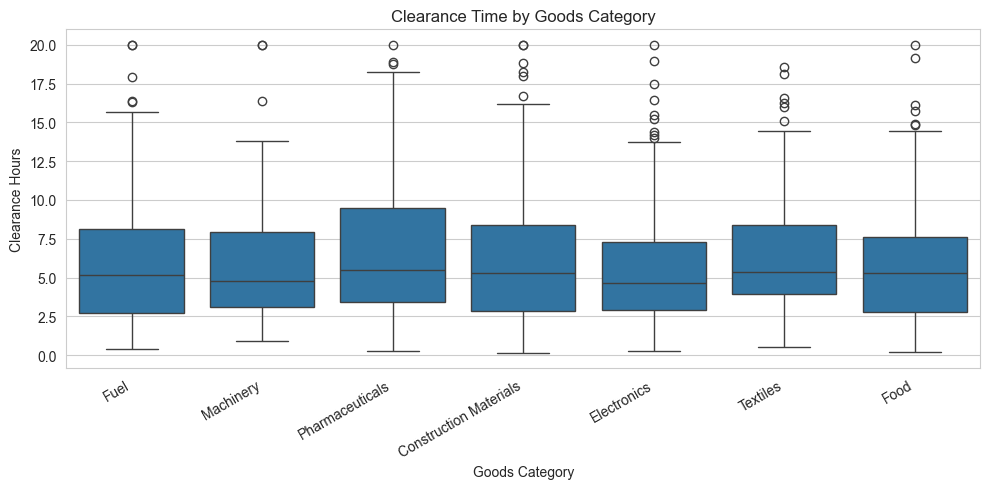

Saved: ../reports/figures\04_clearance_by_goods_boxplot.png


In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="goods_category", y="clearance_hours")
plt.title("Clearance Time by Goods Category")
plt.xlabel("Goods Category")
plt.ylabel("Clearance Hours")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "04_clearance_by_goods_boxplot.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

#### Operational Drivers (Rain + Fuel + Weight/Value)

##### Rain vs clearance time

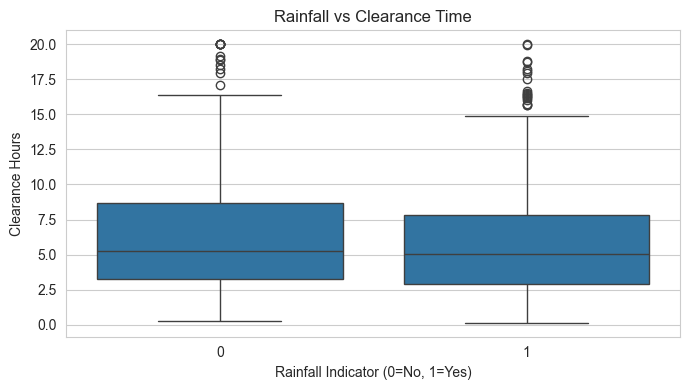

Saved: ../reports/figures\05_rain_vs_clearance.png


In [ ]:
# -----------------------------
# Rain impact (boxplot)
# -----------------------------
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="rainfall_indicator", y="clearance_hours")
plt.title("Rainfall vs Clearance Time")
plt.xlabel("Rainfall Indicator (0=No, 1=Yes)")
plt.ylabel("Clearance Hours")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "05_rain_vs_clearance.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

##### Fuel price vs total transit time

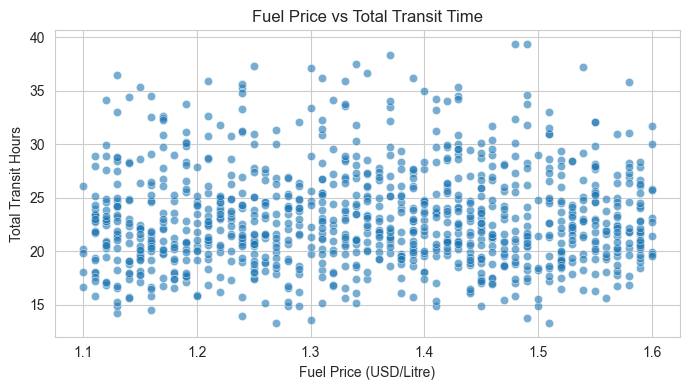

Saved: ../reports/figures\06_fuel_vs_transit_scatter.png


In [ ]:
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="fuel_price_usd_per_litre",
    y="total_transit_hours",
    alpha=0.6
)
plt.title("Fuel Price vs Total Transit Time")
plt.xlabel("Fuel Price (USD/Litre)")
plt.ylabel("Total Transit Hours")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "06_fuel_vs_transit_scatter.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

##### Weight/value impact (do heavier or higher value shipments delay more?)

In [ ]:
# Compare average delay rate by flags created in Notebook 02
flag_summary = df.groupby(["is_heavy", "is_high_value"])["is_delayed"].mean().reset_index()
flag_summary["delay_rate_pct"] = flag_summary["is_delayed"] * 100
flag_summary

,is_heavy,is_high_value,is_delayed,delay_rate_pct
0,0,0,0.114451,11.445087
1,0,1,0.057143,5.714286
2,1,0,0.057143,5.714286
3,1,1,0.061538,6.153846


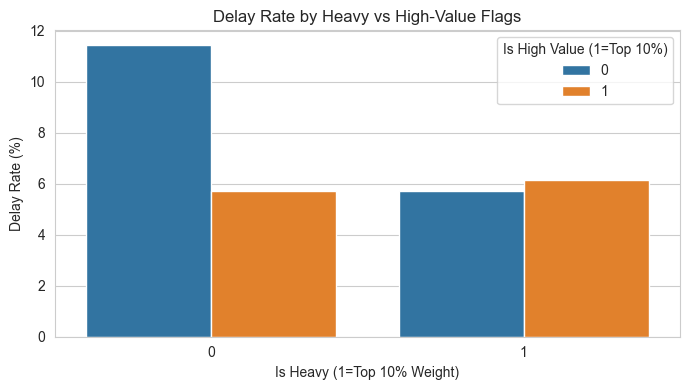

Saved: ../reports/figures\07_delay_by_heavy_highvalue.png


In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=flag_summary, x="is_heavy", y="delay_rate_pct", hue="is_high_value")
plt.title("Delay Rate by Heavy vs High-Value Flags")
plt.xlabel("Is Heavy (1=Top 10% Weight)")
plt.ylabel("Delay Rate (%)")
plt.legend(title="Is High Value (1=Top 10%)")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "07_delay_by_heavy_highvalue.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

##### Delay Reasons (only delayed shipments)

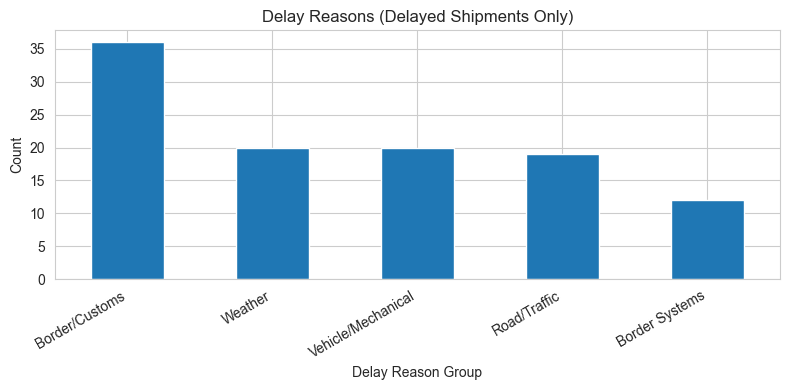

Saved: ../reports/figures\08_delay_reasons.png


In [ ]:
# -----------------------------
# Delay reason frequency among delayed shipments
# -----------------------------
delays = df[df["is_delayed"] == 1]

reason_counts = delays["delay_reason_group"].value_counts()

plt.figure(figsize=(8, 4))
reason_counts.plot(kind="bar")
plt.title("Delay Reasons (Delayed Shipments Only)")
plt.xlabel("Delay Reason Group")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "08_delay_reasons.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

#### 9. Time Trends (Proper Date-Based Trends)

##### 9.0 Create time grouping columns

In [ ]:
df = df.sort_values("depart_time").copy()

df["depart_date"] = df["depart_time"].dt.date
df["depart_week"] = df["depart_time"].dt.to_period("W").astype(str)
df["depart_month"] = df["depart_time"].dt.to_period("M").astype(str)

df[["depart_time", "depart_date", "depart_week", "depart_month"]].head()

,depart_time,depart_date,depart_week,depart_month
0,2024-01-01 03:00:00,2024-01-01,2024-01-01/2024-01-07,2024-01
1,2024-01-01 12:00:00,2024-01-01,2024-01-01/2024-01-07,2024-01
2,2024-01-01 16:00:00,2024-01-01,2024-01-01/2024-01-07,2024-01
3,2024-01-01 19:00:00,2024-01-01,2024-01-01/2024-01-07,2024-01
4,2024-01-02 00:00:00,2024-01-02,2024-01-01/2024-01-07,2024-01


##### 9.1 Daily shipment volume

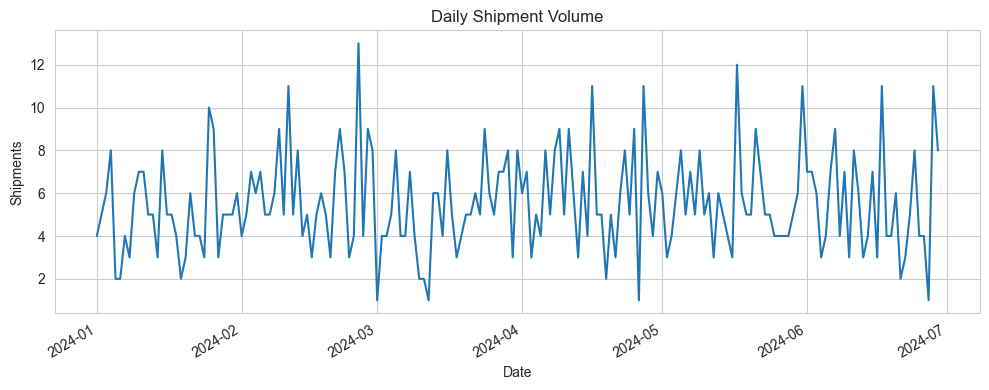

Saved: ../reports/figures\09_daily_shipment_volume.png


In [ ]:
daily_volume = df.groupby("depart_date").size().reset_index(name="shipments")
daily_volume["depart_date"] = pd.to_datetime(daily_volume["depart_date"])

plt.figure(figsize=(10, 4))
plt.plot(daily_volume["depart_date"], daily_volume["shipments"])
plt.title("Daily Shipment Volume")
plt.xlabel("Date")
plt.ylabel("Shipments")
plt.xticks(rotation=30, ha="right")
save_show("09_daily_shipment_volume.png")

##### 9.2 Weekly average clearance time

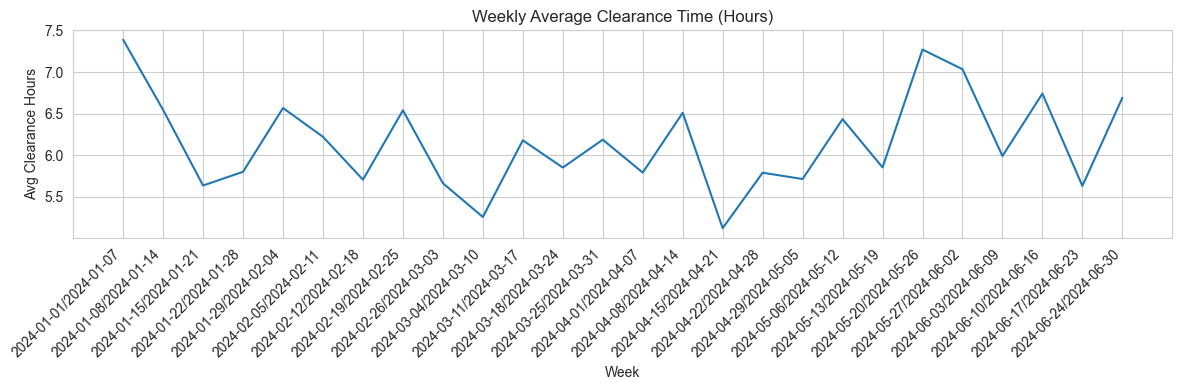

Saved: ../reports/figures\10_weekly_avg_clearance.png


In [ ]:
weekly_clearance = (
    df.groupby("depart_week")["clearance_hours"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 4))
plt.plot(weekly_clearance["depart_week"], weekly_clearance["clearance_hours"])
plt.title("Weekly Average Clearance Time (Hours)")
plt.xlabel("Week")
plt.ylabel("Avg Clearance Hours")
plt.xticks(rotation=45, ha="right")
save_show("10_weekly_avg_clearance.png")

##### 9.3 Monthly delay rate

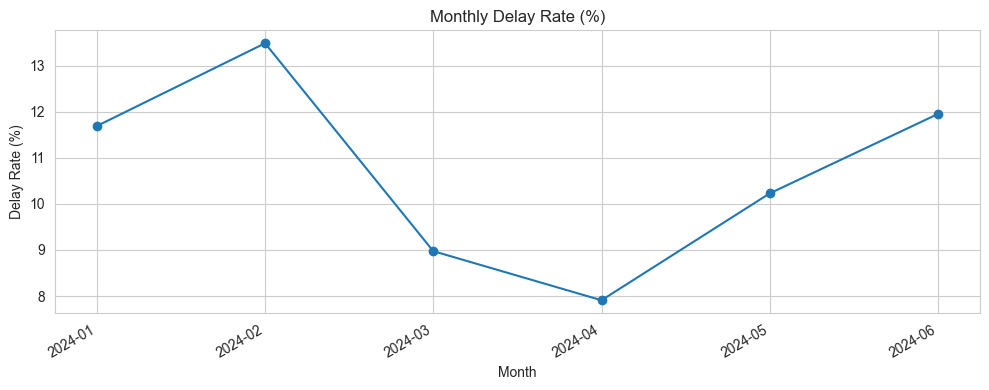

Saved: ../reports/figures\11_monthly_delay_rate.png


In [ ]:
monthly_delay = (
    df.groupby("depart_month")["is_delayed"]
      .mean()
      .reset_index()
)
monthly_delay["delay_rate_pct"] = monthly_delay["is_delayed"] * 100

plt.figure(figsize=(10, 4))
plt.plot(monthly_delay["depart_month"], monthly_delay["delay_rate_pct"], marker="o")
plt.title("Monthly Delay Rate (%)")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=30, ha="right")
save_show("11_monthly_delay_rate.png")

##### 9.4 Monthly total delay cost

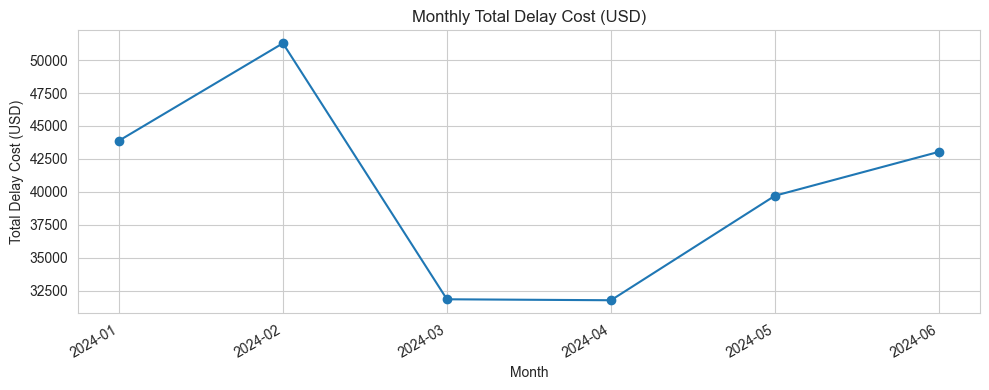

Saved: ../reports/figures\12_monthly_delay_cost.png


In [ ]:
monthly_cost = (
    df.groupby("depart_month")["delay_cost_usd"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10, 4))
plt.plot(monthly_cost["depart_month"], monthly_cost["delay_cost_usd"], marker="o")
plt.title("Monthly Total Delay Cost (USD)")
plt.xlabel("Month")
plt.ylabel("Total Delay Cost (USD)")
plt.xticks(rotation=30, ha="right")
save_show("12_monthly_delay_cost.png")

##### 9.5 Daily clearance with rolling 7-day average

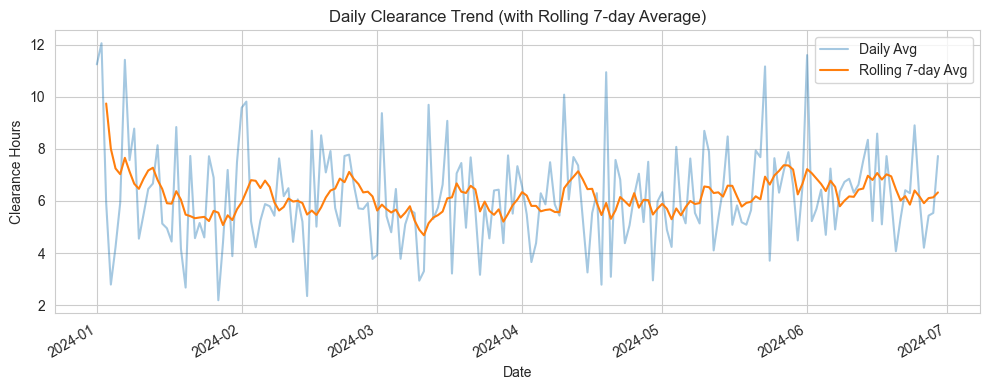

Saved: ../reports/figures\13_daily_clearance_with_rolling7d.png


In [ ]:
daily_clearance = (
    df.groupby("depart_date")["clearance_hours"]
      .mean()
      .reset_index()
)
daily_clearance["depart_date"] = pd.to_datetime(daily_clearance["depart_date"])
daily_clearance["rolling_7d"] = daily_clearance["clearance_hours"].rolling(7, min_periods=3).mean()

plt.figure(figsize=(10, 4))
plt.plot(daily_clearance["depart_date"], daily_clearance["clearance_hours"], alpha=0.4, label="Daily Avg")
plt.plot(daily_clearance["depart_date"], daily_clearance["rolling_7d"], label="Rolling 7-day Avg")
plt.title("Daily Clearance Trend (with Rolling 7-day Average)")
plt.xlabel("Date")
plt.ylabel("Clearance Hours")
plt.xticks(rotation=30, ha="right")
plt.legend()
save_show("13_daily_clearance_with_rolling7d.png")

##### 9.6 Heatmap: weekly clearance by day-of-week

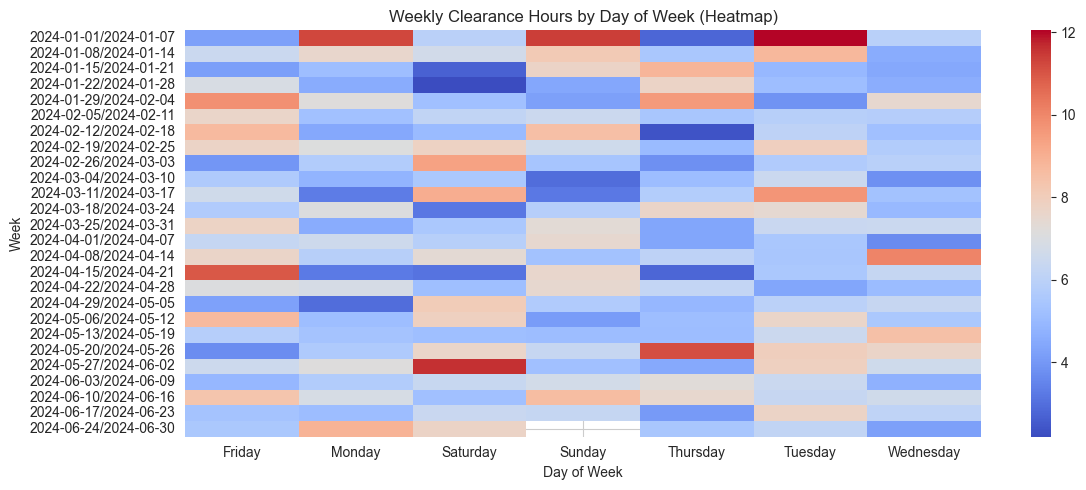

Saved: ../reports/figures\14_weekly_dow_clearance_heatmap.png


In [ ]:
pivot = df.pivot_table(
    index="depart_week",
    columns="depart_day_name",
    values="clearance_hours",
    aggfunc="mean"
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Weekly Clearance Hours by Day of Week (Heatmap)")
plt.xlabel("Day of Week")
plt.ylabel("Week")
save_show("14_weekly_dow_clearance_heatmap.png")

#### Correlation Heatmap (Numeric Features)

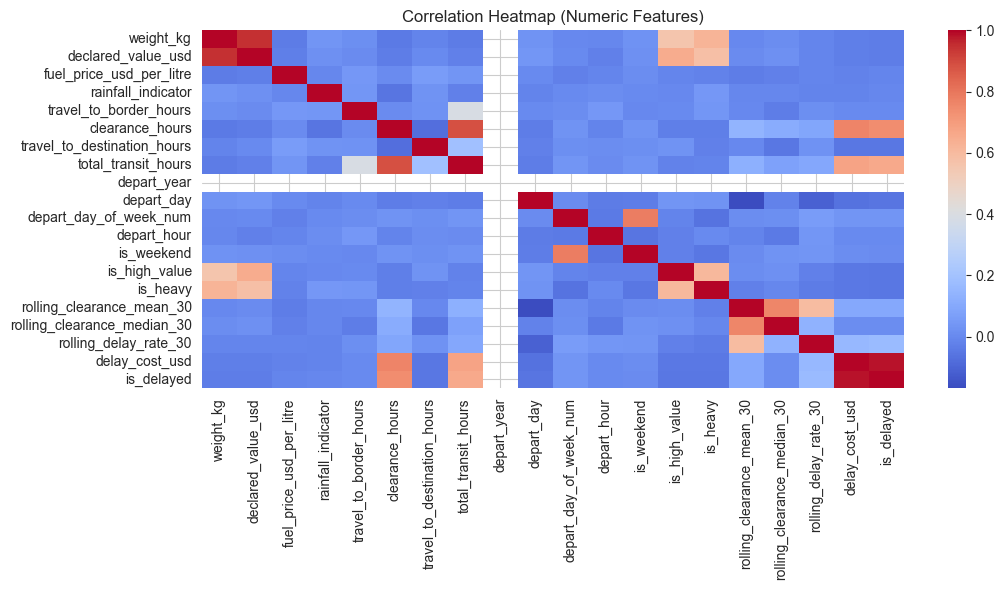

Saved: ../reports/figures\15_correlation_heatmap.png


In [ ]:
import numpy as np
num = df.select_dtypes(include=[np.number]).copy()

plt.figure(figsize=(11, 6))
sns.heatmap(num.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
save_show("15_correlation_heatmap.png")

#### Cost Impact

##### 11.1 Total delay cost by goods category

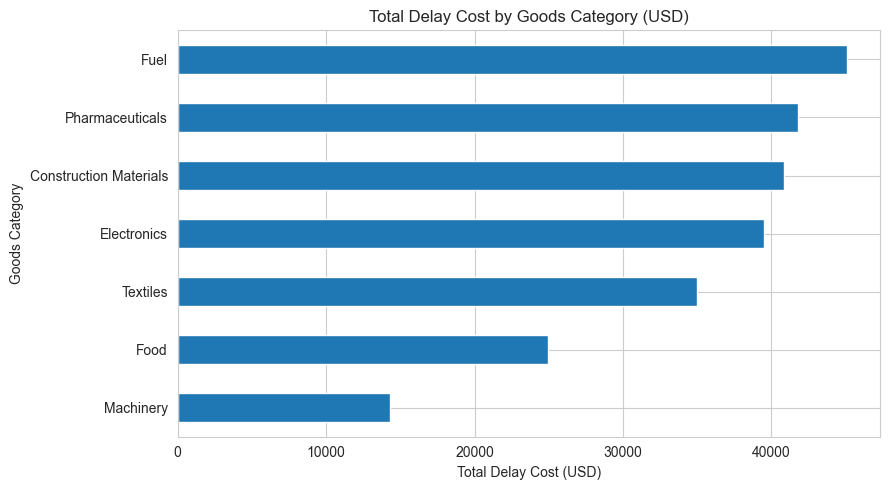

Saved: ../reports/figures\16_total_delay_cost_by_goods.png


In [ ]:
cost_by_goods = (
    df.groupby("goods_category")["delay_cost_usd"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
cost_by_goods.plot(kind="barh")
plt.title("Total Delay Cost by Goods Category (USD)")
plt.xlabel("Total Delay Cost (USD)")
plt.ylabel("Goods Category")
save_show("16_total_delay_cost_by_goods.png")

##### 11.2 Top 10 most expensive delays

In [ ]:
top10 = df.sort_values("delay_cost_usd", ascending=False).head(10)[
    ["shipment_id", "depart_time", "goods_category", "clearance_hours", "delay_cost_usd", "delay_reason_group"]
]
top10

,shipment_id,depart_time,goods_category,clearance_hours,delay_cost_usd,delay_reason_group
845,SHP00504,2024-06-01 14:00:00,Construction Materials,20.000000,3000.000000,Road/Traffic
155,SHP00844,2024-02-01 11:00:00,Construction Materials,20.000000,3000.000000,Border/Customs
2,SHP00639,2024-01-01 16:00:00,Machinery,20.000000,3000.000000,Weather
126,SHP00730,2024-01-26 15:00:00,Food,20.000000,3000.000000,Weather
336,SHP00070,2024-03-02 23:00:00,Electronics,20.000000,3000.000000,Border/Customs
723,SHP00134,2024-05-11 03:00:00,Pharmaceuticals,20.000000,3000.000000,Border/Customs
30,SHP00377,2024-01-07 20:00:00,Machinery,20.000000,3000.000000,Border Systems
31,SHP00822,2024-01-08 04:00:00,Fuel,20.000000,3000.000000,Vehicle/Mechanical
258,SHP00338,2024-02-18 15:00:00,Fuel,19.958048,2993.707260,Border/Customs
842,SHP00221,2024-06-01 02:00:00,Food,19.180057,2877.008547,Weather


#### Simple Savings Simulation
“If we reduce clearance time by 2 hours for every delayed shipment, what’s the estimated savings?”

In [ ]:
COST_PER_HOUR = 150
improvement_hours = 2

# savings per delayed shipment = min(clearance_hours, improvement_hours) * cost_per_hour
savings = np.where(
    df["is_delayed"] == 1,
    np.minimum(df["clearance_hours"], improvement_hours) * COST_PER_HOUR,
    0
)

print(f"Estimated savings (2-hour improvement on delayed shipments): ${savings.sum():,.2f}")

Estimated savings (2-hour improvement on delayed shipments): $32,100.00


In [ ]:
from IPython.display import display, Markdown
import numpy as np

# -----------------------------
# Core Metrics
# -----------------------------
delay_rate = df["is_delayed"].mean() * 100
p90_clearance = df["clearance_hours"].quantile(0.90)

# Rain impact
median_clearance_rain = df[df["rainfall_indicator"] == 1]["clearance_hours"].median()
median_clearance_no_rain = df[df["rainfall_indicator"] == 0]["clearance_hours"].median()
rain_diff = median_clearance_rain - median_clearance_no_rain

# Top delay reason group
top_reason = (
    df[df["is_delayed"] == 1]["delay_reason_group"]
    .value_counts()
    .idxmax()
)

# Biggest delay cost category
top_cost_category = (
    df.groupby("goods_category")["delay_cost_usd"]
    .sum()
    .idxmax()
)

# Savings simulation (2-hour improvement)
COST_PER_HOUR = 150
improvement_hours = 2

savings = np.where(
    df["is_delayed"] == 1,
    np.minimum(df["clearance_hours"], improvement_hours) * COST_PER_HOUR,
    0
)

total_savings = savings.sum()

# -----------------------------
# Markdown Output
# -----------------------------
markdown_text = f"""
# Executive Insights

- **Delay rate is {delay_rate:.2f}%**, with a **P90 clearance time of {p90_clearance:.2f} hours**, indicating that while most shipments clear efficiently, a measurable minority experience extended delays.

- **Rainfall increases median clearance time by approximately {rain_diff:.2f} hours**, suggesting weather-related operational strain at the corridor.

- The **most common delay reason group is '{top_reason}'**, indicating that this is the dominant operational bottleneck.

- The **goods category contributing the highest total delay cost is '{top_cost_category}'**, meaning efficiency improvements in this segment would produce the greatest financial benefit.

- Weekly and rolling trend analysis suggests that congestion occurs in waves rather than randomly, indicating cyclical operational stress.

- A **2-hour reduction in clearance time for delayed shipments could save approximately ${total_savings:,.2f} in this sample dataset**, demonstrating that even small efficiency gains yield significant economic impact.
"""

display(Markdown(markdown_text))


# Executive Insights

- **Delay rate is 10.70%**, with a **P90 clearance time of 12.31 hours**, indicating that while most shipments clear efficiently, a measurable minority experience extended delays.

- **Rainfall increases median clearance time by approximately -0.23 hours**, suggesting weather-related operational strain at the corridor.

- The **most common delay reason group is 'Border/Customs'**, indicating that this is the dominant operational bottleneck.

- The **goods category contributing the highest total delay cost is 'Fuel'**, meaning efficiency improvements in this segment would produce the greatest financial benefit.

- Weekly and rolling trend analysis suggests that congestion occurs in waves rather than randomly, indicating cyclical operational stress.

- A **2-hour reduction in clearance time for delayed shipments could save approximately $32,100.00 in this sample dataset**, demonstrating that even small efficiency gains yield significant economic impact.
